In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def bairstow_step(a, r, s):
    """
    Executa uma única iteração do método de Bairstow.
    Retorna os novos r, s e o erro máximo.
    """
    n = len(a) - 1
    b = np.zeros(n + 1)
    c = np.zeros(n + 1)
    
    # Cálculo dos coeficientes b (divisão sintética)
    b[n] = a[n]
    b[n-1] = a[n-1] + r * b[n]
    for i in range(n-2, -1, -1):
        b[i] = a[i] + r * b[i+1] + s * b[i+2]
        
    # Cálculo dos coeficientes c (derivadas)
    c[n] = b[n]
    c[n-1] = b[n-1] + r * c[n]
    for i in range(n-2, 1, -1):
        c[i] = b[i] + r * c[i+1] + s * c[i+2]
        
    # Sistema linear:
    # c[2]*dr + c[3]*ds = -b[1]
    # c[1]*dr + c[2]*ds = -b[0]
    
    det = c[2]**2 - c[1]*c[3]
    if abs(det) < 1e-12:
        return r, s, 1e10 # Evita divisão por zero
        
    dr = (-b[1] * c[2] + b[0] * c[3]) / det
    ds = (-b[0] * c[2] + b[1] * c[1]) / det
    
    return r + dr, s + ds, max(abs(dr), abs(ds))

def solve_bairstow(a_coeff, r0, s0, tol=1e-5, max_iter=100):
    """Encontra um par de raízes dado um chute r0, s0."""
    r, s = r0, s0
    for i in range(max_iter):
        r, s, err = bairstow_step(a_coeff, r, s)
        if err < tol:
            return r, s, i
    return r, s, max_iter

# --- GERANDO O FRACTAL ---

def gerar_fractal(polinomio, res=150):
    """
    Cria a imagem do fractal baseada na velocidade de convergência.
    r no eixo x, s no eixo y.
    """
    r_range = np.linspace(-5, 5, res)
    s_range = np.linspace(-5, 5, res)
    img = np.zeros((res, res))
    
    for i in range(res):
        for j in range(res):
            _, _, iters = solve_bairstow(polinomio, r_range[i], s_range[j])
            img[j, i] = iters # Armazena o número de iterações
            
    plt.figure(figsize=(10, 8))
    plt.imshow(img, extent=[-5, 5, -5, 5], origin='lower', cmap='magma')
    plt.colorbar(label='Número de Iterações')
    plt.title('Fractal de Bairstow (Bacias de Atração)')
    plt.xlabel('Parâmetro r')
    plt.ylabel('Parâmetro s')
    plt.show()


Par (r,s) encontrado: r=1.0000, s=2.0000 em 7 iterações
Raízes 1 e 2: 2.000000264049036 e -1.0000001650291859
Gerando fractal... aguarde.


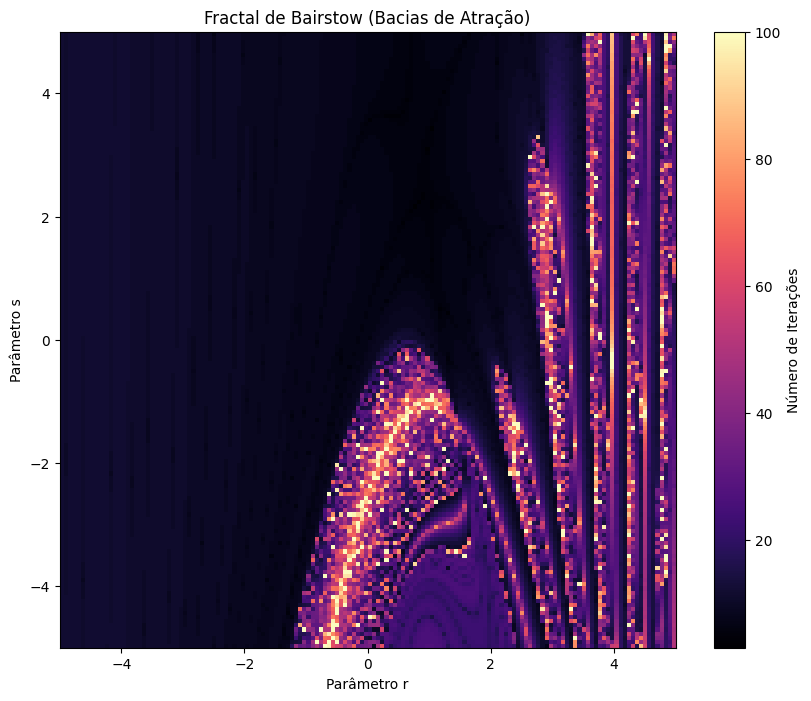

In [5]:
# --- EXEMPLO DE USO ---
# Polinômio: x^4 - 3x^3 + 5x^2 - x - 10
# Coeficientes em ordem crescente: a0, a1, a2, a3, a4
coeficientes = np.array([-10.0, -1.0, 5.0, -3.0, 1.0])

# 1. Encontrar um par de raízes específico
r_final, s_final, it = solve_bairstow(coeficientes, -1.0, -1.0)
print(f"Par (r,s) encontrado: r={r_final:.4f}, s={s_final:.4f} em {it} iterações")

# Raízes do fator quadrático x^2 - rx - s
delta = r_final**2 + 4*s_final
x1 = (r_final + np.lib.scimath.sqrt(delta)) / 2
x2 = (r_final - np.lib.scimath.sqrt(delta)) / 2
print(f"Raízes 1 e 2: {x1} e {x2}")

# 2. Gerar o Fractal
print("Gerando fractal... aguarde.")
gerar_fractal(coeficientes)